simulate_id for each method

In [19]:
##########fat_tree, k = 4, bond, load = 49%
# fecmp_id = 497547479
# conweave_id = 907715927
# CAVER_id = 545564951

##########fat_tree, k = 4, bond, load = 60%
# fecmp_id = 176527761
# conweave_id = 918924462
# CAVER_id = 744923884

##########fat_tree, k = 4, bond, load = 70%
# fecmp_id = 891307306
# conweave_id = 745578601
# CAVER_id = 414623077

##########fat_tree, k = 4, no bond, load = 48%
fecmp_id = 547248488
conweave_id = 837015620
CAVER_id = 548337622

show fct

In [20]:
C = [
    'xkcd:grass green',
    'xkcd:blue',
    'xkcd:purple',
    'xkcd:orange',
    'xkcd:teal',
    'xkcd:brick red',
    'xkcd:black',
    'xkcd:brown',
    'xkcd:grey',
]

LS = [
    'solid',
    'dashed',
    'dotted',
    'dashdot'
]



import subprocess

def get_pctl(a, p):
	i = int(len(a) * p)
	return a[i]

def size2str(steps):
    result = []
    for step in steps:
        if step < 10000:
            result.append("{:.1f}K".format(step / 1000))
        elif step < 1000000:
            result.append("{:.0f}K".format(step / 1000))
        else:
            result.append("{:.1f}M".format(step / 1000000))

    return result

def get_steps_from_raw(id, step=5):
    filename = f"../mix/output/{id}/{id}_out_fct.txt"
    time_start = int(2.000 * 1000000000)
    time_end = int(3.0 * 1000000000) 
    cmd_slowdown = "cat %s"%(filename)+" | awk '{ if ($6>"+"%d"%time_start+" && $6+$7<"+"%d"%(time_end)+") { slow=$7/$8; print slow<1?1:slow, $5} }' | sort -n -k 2"    
    output_slowdown = subprocess.check_output(cmd_slowdown, shell=True)
    aa = output_slowdown.decode("utf-8").split('\n')[:-2]
    nn = len(aa)

    # CDF of FCT
    res = [[i/100.] for i in range(0, 100, step)]
    for i in range(0,100,step):
        l = int(i * nn / 100)
        r = int((i+step) * nn / 100)
        fct_size = aa[l:r]
        fct_size = [[float(x.split(" ")[0]), int(x.split(" ")[1])] for x in fct_size]
        fct = sorted(map(lambda x: x[0], fct_size))
        
        res[int(i/step)].append(fct_size[-1][1]) # flow size
        
        res[int(i/step)].append(sum(fct) / len(fct)) # avg fct
        res[int(i/step)].append(get_pctl(fct, 0.5)) # mid fct
        res[int(i/step)].append(get_pctl(fct, 0.95)) # 95-pct fct
        res[int(i/step)].append(get_pctl(fct, 0.99)) # 99-pct fct
        res[int(i/step)].append(get_pctl(fct, 0.999)) # 99-pct fct
    

    result = {"avg": [], "p99": [], "size": []}
    for item in res:
        # if item[1] / (10 ** 3) <= 400:
            result["avg"].append(item[2])
            result["p99"].append(item[5])
            result["size"].append(item[1] / (10 ** 3))

    return result
    

bandwidth

FCT显示

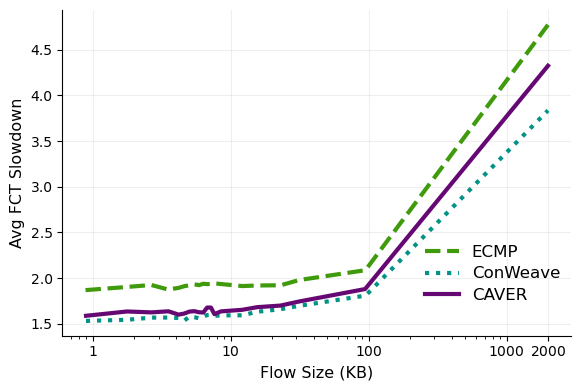

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.backends.backend_pdf import PdfPages

pdf = PdfPages('plot.pdf')
fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
STEP = 5
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel("Flow Size (KB)", fontsize=11.5)
ax.set_ylabel("Avg FCT Slowdown", fontsize=11.5)

xvals = [i for i in range(STEP, 100 + STEP, STEP)]

lb_mode = "ECMP"
ecmp_result = get_steps_from_raw(fecmp_id, STEP)
# ax.plot(xvals, result["avg"], markersize=1.0, linewidth=3.0, label="{}".format(lb_mode), linestyle=LS[1])
ax.plot(ecmp_result["size"], ecmp_result["avg"], markersize=1.0, linewidth=3.0, label="{}".format(lb_mode), linestyle=LS[1], color = 'xkcd:grass green')

# lb_mode = "conga"
# result = get_steps_from_raw(conga_id, STEP)
# # ax.plot(xvals, result["avg"], markersize=1.0, linewidth=3.0, label="{}".format(lb_mode), linestyle=LS[1])
# ax.plot(result["size"], result["avg"], markersize=1.0, linewidth=3.0, label="{}".format(lb_mode), linestyle=LS[1], color = 'xkcd:orange')

lb_mode = "ConWeave"
conweave_result = get_steps_from_raw(conweave_id, STEP)
ax.plot(conweave_result["size"], conweave_result["avg"], markersize=1.0, linewidth=3.0, label="{}".format(lb_mode), linestyle=LS[2], color = 'xkcd:teal')

lb_mode = "CAVER"
caver_result = get_steps_from_raw(CAVER_id, STEP)
ax.plot(caver_result["size"], caver_result["avg"], markersize=1.0, linewidth=3.0, label="{}".format(lb_mode), linestyle=LS[0], color=(102 / 255, 8 / 255, 116 / 255))

ax.grid(which='minor', alpha=0.2)
ax.grid(which='major', alpha=0.5)

# 0.0,1.2
ax.legend(bbox_to_anchor=(0.7, 0.3), loc="upper left", borderaxespad=0,
        frameon=False, fontsize=12, facecolor='white', ncol=1,
        labelspacing=0.4, columnspacing=0.8)

ax.set_xscale('log')
# log_ticks = np.log10([1, 10, 10 ** 2])  # 将线性值转换为对数值
log_ticks = np.log10([1, 10, 10 ** 2, 10 ** 3, 2 * (10 ** 3)])  # 将线性值转换为对数值
ax.set_xticks(10 ** log_ticks)
# ax.set_xticklabels([r"$1$", r"$10$", r"$100$"])
ax.set_xticklabels([r"$1$", r"$10$", r"$100$", r"$1000$", r"$2000$"])

ax.grid(True, which='major')

# 关闭次要刻度线
ax.grid(False, which='minor')

# 显示网格线的透明度
ax.grid(True, which='major', alpha=0.2)
# ax.set_ylim(1.4, 2.2)
plt.tight_layout() 
pdf.savefig() 
pdf.close()
plt.savefig("plot.png")
plt.show()